In [1]:
# ── CELDA 1: Verificación GPU ─────────────────────────────────────────────────
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"✅ GPU activa: {gpus[0].name}")
else:
    print("⚠️ Sin GPU — cambia: Entorno de ejecución > Cambiar tipo > GPU")

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU activa: /physical_device:GPU:0


In [2]:
# ── CELDA 2: Montar Drive ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

DRIVE_PROJECT = "/content/drive/MyDrive/Instituto/Inteligencia Artificial y Big Data/TFE/mercaintelligence"

Mounted at /content/drive


In [3]:
# ── CELDA 3: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [4]:
# ── CELDA 4: Configuración ────────────────────────────────────────────────────
PARTITIONED_DIR = Path(f"{DRIVE_PROJECT}/data/processed")
MODEL_PATH      = Path(f"{DRIVE_PROJECT}/models/lstm_clasificador.keras")
SCALER_PATH     = Path(f"{DRIVE_PROJECT}/models/lstm_scaler.pkl")
RESULTS_PATH    = Path(f"{DRIVE_PROJECT}/data/anomalias/lstm_resultados.parquet")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

VENTANA         = 14    # días de contexto
HORIZONTE       = 7     # días a predecir
MIN_DIAS        = VENTANA + HORIZONTE + 5
EPOCHS          = 50
BATCH_SIZE      = 256
VALIDATION_SPLIT = 0.15

In [5]:
# ── CELDA 5: Carga y feature engineering ─────────────────────────────────────
cols = ["referencia", "fecha", "precio_actual", "precio_por_medida",
        "categoria", "subcategoria", "marca_propia"]

df = pd.read_parquet(PARTITIONED_DIR, columns=cols)
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values(["referencia", "fecha"]).reset_index(drop=True)

# Features temporales
df["precio_anterior"] = df.groupby("referencia")["precio_actual"].shift(1)
df["variacion_pct"]   = (
    (df["precio_actual"] - df["precio_anterior"]) / df["precio_anterior"]
).fillna(0.0)

df["precio_cambio"]   = df.groupby("referencia")["precio_actual"].shift(1) != df["precio_actual"]
df["grupo_cambio"]    = df.groupby("referencia")["precio_cambio"].cumsum()
df["dias_sin_cambio"] = df.groupby(["referencia", "grupo_cambio"]).cumcount()

# Ratio vs media de subcategoría (mismo que IF)
media_subcat = df.groupby(["subcategoria", "fecha"], observed=True)["precio_actual"].transform("mean")
df["ratio_vs_subcat"] = (df["precio_actual"] / media_subcat).round(4)

# Normalización min-max por producto
for col in ["precio_actual", "precio_por_medida", "dias_sin_cambio"]:
    mn = df.groupby("referencia")[col].transform("min")
    mx = df.groupby("referencia")[col].transform("max")
    rango = (mx - mn).replace(0, 1)
    df[f"{col}_norm"] = ((df[col] - mn) / rango).round(6)

df = df.drop(columns=["precio_anterior", "precio_cambio", "grupo_cambio"])
print(f"Datos: {len(df):,} filas | {df['referencia'].nunique():,} productos")
print(f"Columnas: {list(df.columns)}")

Datos: 694,446 filas | 5,042 productos
Columnas: ['referencia', 'fecha', 'precio_actual', 'precio_por_medida', 'categoria', 'subcategoria', 'marca_propia', 'variacion_pct', 'dias_sin_cambio', 'ratio_vs_subcat', 'precio_actual_norm', 'precio_por_medida_norm', 'dias_sin_cambio_norm']


In [6]:
# ── CELDA 6: Construcción de secuencias con etiqueta ─────────────────────────
"""
Para cada producto, construimos ventanas deslizantes:
  X: features de los últimos VENTANA días
  y: ¿hubo cambio de precio en los próximos HORIZONTE días? (0/1)

El desbalance de clases es esperado y severo:
  ~95% de los días no hay cambio → clase 0 mayoritaria
  ~5% hay cambio → clase 1 minoritaria
Lo gestionamos con class_weight en el entrenamiento.
"""
FEATURES = ["precio_actual_norm", "precio_por_medida_norm",
            "variacion_pct", "dias_sin_cambio_norm", "ratio_vs_subcat"]

X_list, y_list, meta_list = [], [], []

for ref, grupo in df.groupby("referencia"):
    grupo = grupo.sort_values("fecha").reset_index(drop=True)
    if len(grupo) < MIN_DIAS:
        continue

    precios = grupo["precio_actual"].values
    vals    = grupo[FEATURES].values
    fechas  = grupo["fecha"].values

    for i in range(VENTANA, len(grupo) - HORIZONTE):
        secuencia = vals[i - VENTANA : i]

        # Etiqueta: ¿cambia el precio en los próximos HORIZONTE días?
        precios_futuros = precios[i : i + HORIZONTE]
        precio_actual   = precios[i - 1]
        hubo_cambio     = int(np.any(precios_futuros != precio_actual))

        X_list.append(secuencia)
        y_list.append(hubo_cambio)
        meta_list.append((ref, fechas[i]))

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)

print(f"Secuencias totales : {len(X):,}")
print(f"Shape X            : {X.shape}")
print(f"Clase 0 (no cambia): {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")
print(f"Clase 1 (cambia)   : {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)")

Secuencias totales : 590,671
Shape X            : (590671, 14, 5)
Clase 0 (no cambia): 565,365 (95.7%)
Clase 1 (cambia)   : 25,306 (4.3%)


In [7]:
# ── CELDA 7: Train / Val / Test split temporal ───────────────────────────────
"""
Split temporal estricto en 3 conjuntos (Train 70% / Val 15% / Test 15%).
Evitamos data leakage y permitimos optimización de hiperparámetros (threshold) en Val.
"""
fechas_series = pd.Series([m[1] for m in meta_list])
fecha_corte_val = fechas_series.quantile(0.70)
fecha_corte_test = fechas_series.quantile(0.85)

idx_train = (fechas_series < fecha_corte_val).values
idx_val   = ((fechas_series >= fecha_corte_val) & (fechas_series < fecha_corte_test)).values
idx_test  = (fechas_series >= fecha_corte_test).values

X_train, X_val, X_test = X[idx_train], X[idx_val], X[idx_test]
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]

print(f"Train: {len(X_train):,} secuencias | hasta {fecha_corte_val.date()}")
print(f"Val  : {len(X_val):,} secuencias | desde {fecha_corte_val.date()} hasta {fecha_corte_test.date()}")
print(f"Test : {len(X_test):,} secuencias | desde {fecha_corte_test.date()}")
print(f"Tasa cambio train: {y_train.mean()*100:.1f}%")
print(f"Tasa cambio val  : {y_val.mean()*100:.1f}%")
print(f"Tasa cambio test : {y_test.mean()*100:.1f}%")


Train: 410,036 secuencias | hasta 2026-03-09
Val  : 88,113 secuencias | desde 2026-03-09 hasta 2026-03-30
Test : 92,522 secuencias | desde 2026-03-30
Tasa cambio train: 4.0%
Tasa cambio val  : 4.1%
Tasa cambio test : 5.6%


In [8]:
# ── CELDA 8: Class weights para desbalance ────────────────────────────────────
"""
Con ~95% clase 0 y ~5% clase 1, el modelo sin corrección aprende
a predecir siempre 0 y obtiene 95% de accuracy — inútil.

class_weight penaliza los errores en clase 1 proporcionalmente:
  peso_clase_1 = n_total / (2 * n_clase_1)
  peso_clase_0 = n_total / (2 * n_clase_0)

Esto es equivalente a sobremuestrear la clase minoritaria.
"""
n_total  = len(y_train)
n_clase0 = (y_train == 0).sum()
n_clase1 = (y_train == 1).sum()

peso_0 = n_total / (2 * n_clase0)
peso_1 = n_total / (2 * n_clase1)
class_weight = {0: peso_0, 1: peso_1}

print(f"Class weights → 0: {peso_0:.3f} | 1: {peso_1:.3f}")
print(f"El modelo penaliza {peso_1/peso_0:.1f}x más los errores en clase 1")

Class weights → 0: 0.521 | 1: 12.474
El modelo penaliza 23.9x más los errores en clase 1


In [9]:
# ── CELDA 9: Arquitectura LSTM ────────────────────────────────────────────────
"""
Arquitectura deliberadamente simple:
  LSTM(64) → Dropout(0.3) → LSTM(32) → Dropout(0.2) → Dense(1, sigmoid)

Por qué no más capas:
  Con 14 timesteps y 5 features, una red más profunda overfittearía.
  El Dropout regulariza — crucial con clases desbalanceadas.
  BatchNormalization estabiliza el entrenamiento con class_weight alto.
"""
inputs = Input(shape=(VENTANA, len(FEATURES)), name="input")
x = LSTM(64, return_sequences=True, name="lstm1")(inputs)
x = Dropout(0.3, name="dropout1")(x)
x = LSTM(32, return_sequences=False, name="lstm2")(x)
x = Dropout(0.2, name="dropout2")(x)
x = BatchNormalization(name="bn")(x)
output = Dense(1, activation="sigmoid", name="output")(x)

modelo = Model(inputs, output, name="lstm_clasificador")
modelo.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.AUC(name="auc"),
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)
modelo.summary()

Model: "lstm_clasificador"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 14, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ (None, 14, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn (BatchNormalization)         │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,497 (119.13 KB)

 Trainable params: 30,433 (118.88 KB)

 Non-trainable params: 64 (256.00 B)

In [10]:
# ── CELDA 10: Entrenamiento ───────────────────────────────────────────────────
history = modelo.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    class_weight=class_weight,
    callbacks=[
        EarlyStopping(monitor="val_auc", patience=7,
                      restore_best_weights=True, mode="max", verbose=1),
        ModelCheckpoint(str(MODEL_PATH), monitor="val_auc",
                        save_best_only=True, mode="max", verbose=0),
    ],
    verbose=1,
)
print(f"\n✅ Modelo guardado en {MODEL_PATH}")

Epoch 1/50
1602/1602 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.8224 - auc: 0.8714 - loss: 0.4477 - precision: 0.1554 - recall: 0.7737 - val_accuracy: 0.8127 - val_auc: 0.9419 - val_loss: 0.5113 - val_precision: 0.1734 - val_recall: 0.9372
Epoch 2/50
1602/1602 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8746 - auc: 0.9225 - loss: 0.3527 - precision: 0.2186 - recall: 0.8266 - val_accuracy: 0.8647 - val_auc: 0.9633 - val_loss: 0.4599 - val_precision: 0.2265 - val_recall: 0.9413
Epoch 3/50
1602/1602 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8830 - auc: 0.9368 - loss: 0.3203 - precision: 0.2340 - recall: 0.8442 - val_accuracy: 0.7212 - val_auc: 0.9441 - val_loss: 0.6423 - val_precision: 0.1240 - val_recall: 0.9465
Epoch 4/50
1602/1602 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8827 - auc: 0.9430 - loss: 0.3051 - precision: 0.2345 - recall: 0.8507 - val_accuracy: 0.8549 - val_auc: 0.9692 - val_loss: 0.3634 - val_precision: 0.2152 - val_recall: 0.9476
Epoch 5/50
1602/

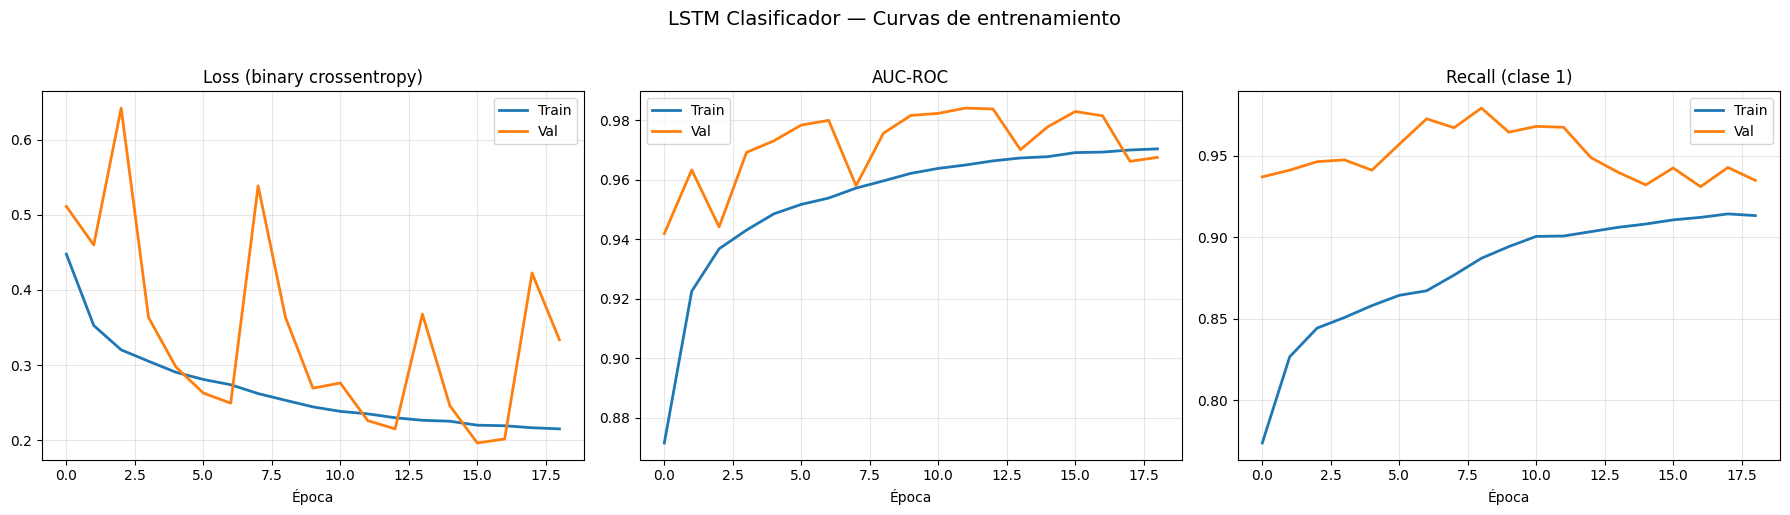

In [11]:
# ── CELDA 11: Curvas de entrenamiento ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metrica, titulo in zip(
    axes,
    ["loss", "auc", "recall"],
    ["Loss (binary crossentropy)", "AUC-ROC", "Recall (clase 1)"]
):
    ax.plot(history.history[metrica], label="Train", linewidth=2)
    ax.plot(history.history[f"val_{metrica}"], label="Val", linewidth=2)
    ax.set_title(titulo)
    ax.set_xlabel("Época")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("LSTM Clasificador — Curvas de entrenamiento", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{DRIVE_PROJECT}/notebooks/lstm_curvas_entrenamiento.png", dpi=150, bbox_inches="tight")
plt.show()

OPTIMIZACIÓN DE THRESHOLD (Conjunto de Validación)
Mejor Threshold (F1-Score máximo): 0.9541
  F1 esperado : 0.7384
  Precisión   : 0.7858
  Recall      : 0.6965



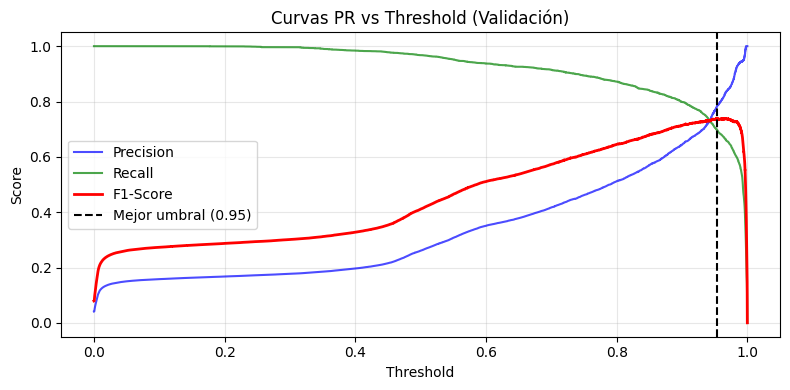

In [12]:
# ── CELDA 11.5: Optimización del Umbral (Threshold) con Precision-Recall ──────
from sklearn.metrics import precision_recall_curve

y_prob_val = modelo.predict(X_val, verbose=0).flatten()
precision_val, recall_val, thresholds_val = precision_recall_curve(y_val, y_prob_val)

# Calcular F1-Score para encontrar el equilibrio óptimo
f1_scores = 2 * (precision_val[:-1] * recall_val[:-1]) / (precision_val[:-1] + recall_val[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds_val[best_idx]

print("=" * 55)
print(f"OPTIMIZACIÓN DE THRESHOLD (Conjunto de Validación)")
print("=" * 55)
print(f"Mejor Threshold (F1-Score máximo): {best_threshold:.4f}")
print(f"  F1 esperado : {f1_scores[best_idx]:.4f}")
print(f"  Precisión   : {precision_val[best_idx]:.4f}")
print(f"  Recall      : {recall_val[best_idx]:.4f}\n")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds_val, precision_val[:-1], label="Precision", color="blue", alpha=0.7)
ax.plot(thresholds_val, recall_val[:-1], label="Recall", color="green", alpha=0.7)
ax.plot(thresholds_val, f1_scores, label="F1-Score", color="red", linewidth=2)
ax.axvline(best_threshold, color="black", linestyle="--", label=f"Mejor umbral ({best_threshold:.2f})")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Curvas PR vs Threshold (Validación)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DRIVE_PROJECT}/notebooks/lstm_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# ── CELDA 12: Evaluación sobre test ──────────────────────────────────────────
y_prob  = modelo.predict(X_test, verbose=0).flatten()
y_pred  = (y_prob >= best_threshold).astype(int)

print("=" * 55)
print(f"EVALUACIÓN LSTM — conjunto test (Threshold={best_threshold:.3f})")
print("=" * 55)
print(classification_report(y_test, y_pred,
                             target_names=["No cambia (0)", "Cambia (1)"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

EVALUACIÓN LSTM — conjunto test (Threshold=0.954)
               precision    recall  f1-score   support

No cambia (0)       0.98      0.92      0.95     87295
   Cambia (1)       0.33      0.66      0.44      5227

     accuracy                           0.91     92522
    macro avg       0.66      0.79      0.70     92522
 weighted avg       0.94      0.91      0.92     92522

AUC-ROC: 0.9147


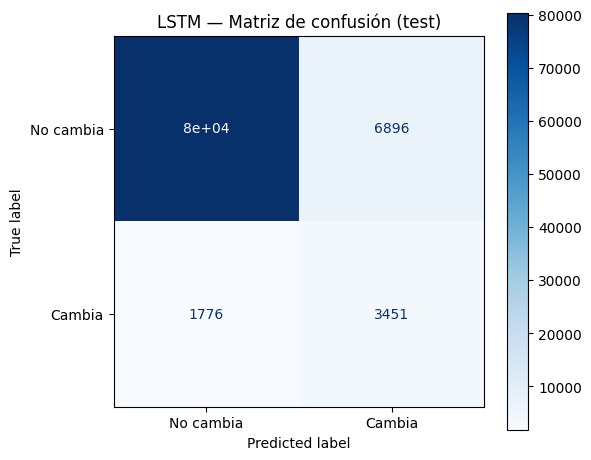

In [14]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No cambia", "Cambia"],
    cmap="Blues", ax=ax
)
ax.set_title("LSTM — Matriz de confusión (test)")
plt.tight_layout()
plt.savefig(f"{DRIVE_PROJECT}/notebooks/lstm_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# ── CELDA 13: Baseline — Logistic Regression ──────────────────────────────────
"""
Comparativa obligatoria para la memoria:
Si el LSTM no supera la Logistic Regression, el Deep Learning
no está añadiendo valor sobre un modelo lineal simple.
Eso también es un resultado válido y honesto — lo que NO se puede
hacer es no comparar.

LR trabaja con features aplanadas (no secuencias temporales),
lo que es su desventaja natural frente al LSTM.
"""
X_train_flat = X_train.reshape(len(X_train), -1)   # (n, 14*5) = (n, 70)
X_val_flat   = X_val.reshape(len(X_val), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_flat)
X_val_sc   = scaler.transform(X_val_flat)
X_test_sc  = scaler.transform(X_test_flat)

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=500,
    random_state=42
)
lr.fit(X_train_sc, y_train)

y_prob_val_lr = lr.predict_proba(X_val_sc)[:, 1]
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
precision_lr, recall_lr, thresh_lr = precision_recall_curve(y_val, y_prob_val_lr)
f1_lr = 2 * (precision_lr[:-1] * recall_lr[:-1]) / (precision_lr[:-1] + recall_lr[:-1] + 1e-10)
best_thresh_lr = thresh_lr[np.argmax(f1_lr)]
y_pred_lr = (y_prob_lr >= best_thresh_lr).astype(int)

print("=" * 55)
print(f"BASELINE — Logistic Regression (Threshold={best_thresh_lr:.3f})")
print("=" * 55)
print(classification_report(y_test, y_pred_lr,
                             target_names=["No cambia (0)", "Cambia (1)"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}")

# Guardar scaler para inferencia local

BASELINE — Logistic Regression (Threshold=0.779)
               precision    recall  f1-score   support

No cambia (0)       0.96      0.97      0.96     87295
   Cambia (1)       0.39      0.32      0.35      5227

     accuracy                           0.93     92522
    macro avg       0.67      0.65      0.66     92522
 weighted avg       0.93      0.93      0.93     92522

AUC-ROC: 0.7551


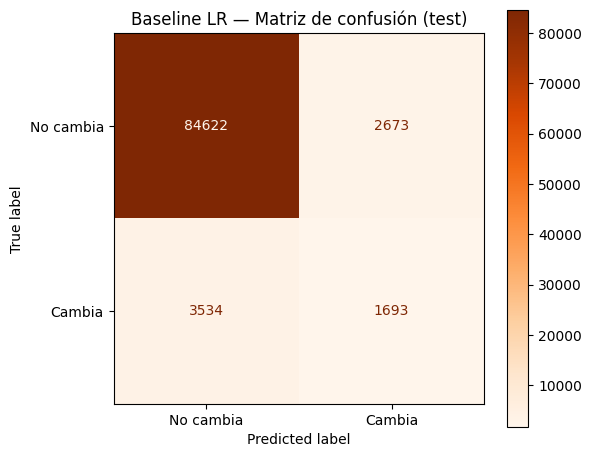

['/content/drive/MyDrive/Instituto/Inteligencia Artificial y Big Data/TFE/mercaintelligence/models/lstm_scaler.pkl']

In [17]:
# Matriz de confusión para Baseline LR
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=["No cambia", "Cambia"],
    cmap="Oranges", ax=ax
)
ax.set_title("Baseline LR — Matriz de confusión (test)")
plt.tight_layout()
plt.savefig(f"{DRIVE_PROJECT}/notebooks/lr_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

joblib.dump(scaler, SCALER_PATH)

In [18]:
# ── CELDA 14: Tabla comparativa LSTM vs LR ───────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

def metricas(y_true, y_pred, y_prob, nombre):
    return {
        "Modelo":     nombre,
        "Precision":  f"{precision_score(y_true, y_pred, zero_division=0):.3f}",
        "Recall":     f"{recall_score(y_true, y_pred, zero_division=0):.3f}",
        "F1-score":   f"{f1_score(y_true, y_pred, zero_division=0):.3f}",
        "AUC-ROC":    f"{roc_auc_score(y_true, y_prob):.3f}",
    }

tabla = pd.DataFrame([
    metricas(y_test, y_pred,    y_prob,    "LSTM"),
    metricas(y_test, y_pred_lr, y_prob_lr, "Logistic Regression (baseline)"),
])
print("\n" + tabla.to_string(index=False))
print("\n→ Esta tabla va directamente a la sección de Evaluación de la memoria")


                        Modelo Precision Recall F1-score AUC-ROC
                          LSTM     0.334  0.660    0.443   0.915
Logistic Regression (baseline)     0.388  0.324    0.353   0.755

→ Esta tabla va directamente a la sección de Evaluación de la memoria


In [19]:
# ── CELDA 15: Inferencia completa y guardado ──────────────────────────────────
"""
Genera predicciones para TODAS las secuencias del histórico.
Estas probabilidades se indexan en ES para el dashboard de predicciones.
"""
X_all = np.array(X_list, dtype=np.float32)
y_prob_all = modelo.predict(X_all, batch_size=512, verbose=1).flatten()

df_resultados = pd.DataFrame(meta_list, columns=["referencia", "fecha"])
df_resultados["prob_cambio_lstm"] = y_prob_all.round(4)
df_resultados["prediccion_cambio"] = (y_prob_all >= best_threshold).astype(int)
df_resultados["y_real"] = y

df_resultados.to_parquet(RESULTS_PATH, index=False)
print(f"✅ Resultados guardados: {len(df_resultados):,} predicciones")
print(f"   En: {RESULTS_PATH}")
print("\nProductos con predicción de cambio próximo:")
print(df_resultados[df_resultados["prediccion_cambio"]==1]["referencia"].nunique(), "productos")

1154/1154 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
✅ Resultados guardados: 590,671 predicciones
   En: /content/drive/MyDrive/Instituto/Inteligencia Artificial y Big Data/TFE/mercaintelligence/data/anomalias/lstm_resultados.parquet

Productos con predicción de cambio próximo:
3946 productos
